# Module 3 Homework - Seaborn
Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://cdn.arstechnica.net/wp-content/uploads/2020/07/pokemon-go-masks-800x450.jpg">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"

# Create pokemon dataframe.
pokemon_df = pd.read_csv(fp)

In [2]:
# Preview dataset.
pokemon_df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Use `hue` to display the `HP` (hit point) for each datapoint. You can choose your favorite palette. Include a meaninful title in the plot. After creating the plot, insert a markdown cell :immediately following the plot to describe the relationship between Attack and Defense in this dataset.

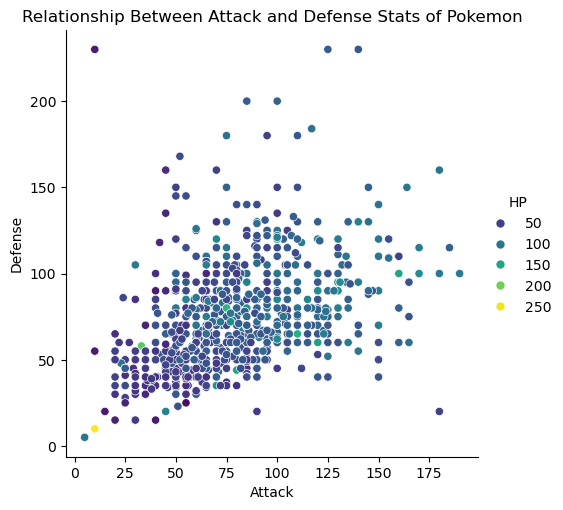

In [7]:
# Use relplot to observe the relationship between the attack and defense stats of pokemon. 
# 1. data=pokemon_df
# 2. x="Attack"
# 3. y="Defense"
# 4. hue="HP"
# 5. palette="viridis"
# 6. plt.title("Relationship Between Attack and Defense Stats of Pokemon")

sns.relplot(data=pokemon_df, x="Attack", y="Defense", hue="HP", palette="viridis")
plt.title("Relationship Between Attack and Defense Stats of Pokemon")
plt.show()

### From the plot, I observed....
(Teacher's) Results: There is a positive correlation between `Attack` and `Defense`. The hit-points (`HP`) is higher for Pokemons with higher `Attack` and `Defense` values.

In [9]:
# I didn't really see the correlation between higher stats -> higher HP so I calculated the correlations to verify.
pokemon_df[["HP", "Attack", "Defense"]].corr()

,HP,Attack,Defense
HP,1.000000,0.422386,0.239622
Attack,0.422386,1.000000,0.438687
Defense,0.239622,0.438687,1.000000


(My modified) results: There is a positive correlation between Attack and Defense. There is a positive correlation between HP and Attack, and a slightly weaker correlation between HP and Defense.

## Q2: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `joinplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot "Attack vs total for all Pokemon". After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Attack` and `Total`, what else does this plot show?

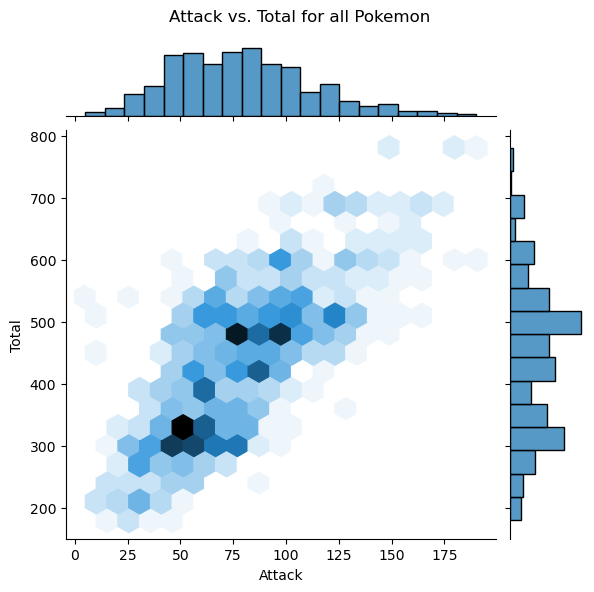

In [19]:
# Use a hexbin plot (sns.jointplot) to display the relationship between Attack and Total.
# 1. data=pokemon_df
# 2. x="Attack"
# 3. y="Total"
# 4. kind="hex"
# 5. gridsize=10
# 6. plt.title("Attack vs. Total for all Pokemon")

figure = sns.jointplot(data=pokemon_df, x="Attack", y="Total", kind="hex")
# Need suptitle to prevent title from getting covered.
figure.fig.suptitle("Attack vs. Total for all Pokemon")
# After putting title at top, we need to make sure it isn't overlapping.
figure.fig.subplots_adjust(top=0.92)  
plt.show()

From the plot, I observed that Attack and Total have a positive correlation, and that most pokemon tend to cluster in the middle for the Attack-Total relationship (Attack: 50-100, Total: 300-500).

## Q3: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

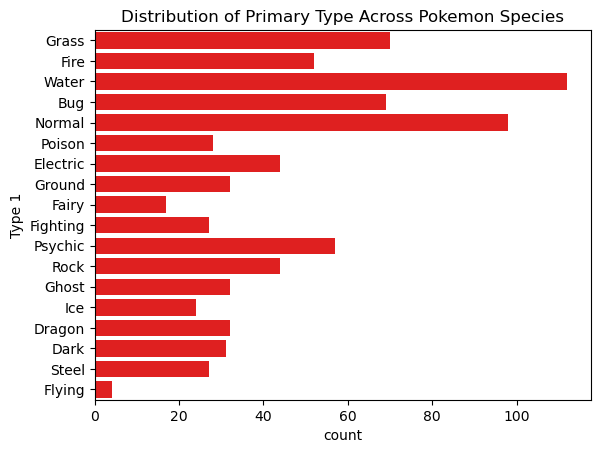

In [22]:
# Since we're displaying the counts of Pokemon, I assume this means we're using a countplot.
# 1. data=pokemon_df
# 2. y="Type 1"
# 3. color="red"
sns.countplot(data=pokemon_df, y="Type 1", color="red")
plt.title("Distribution of Primary Type Across Pokemon Species")
plt.show()

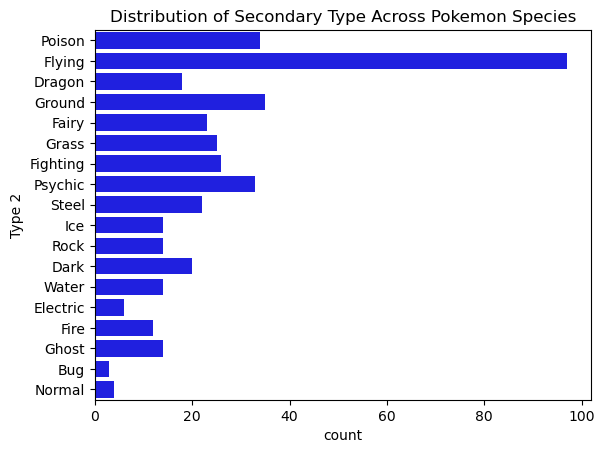

In [23]:
# 1. data=pokemon_df
# 2. y="Type 2"
# 3. color="blue"

sns.countplot(data=pokemon_df, y="Type 2", color="blue")
plt.title("Distribution of Secondary Type Across Pokemon Species")
plt.show()

The most common Type 1 pokemon type is Water type. The most common Type 2 pokemon type is Flying type. The rarest Type 1 pokemon type is Flying type. The rarest Type 2 pokemon type is Bug type.

## Q4-6: Your own question
Come up with three more questions to further explore the pokemon dataset.

### Do legendary pokemon have higher total stats compared to non-legendaries?

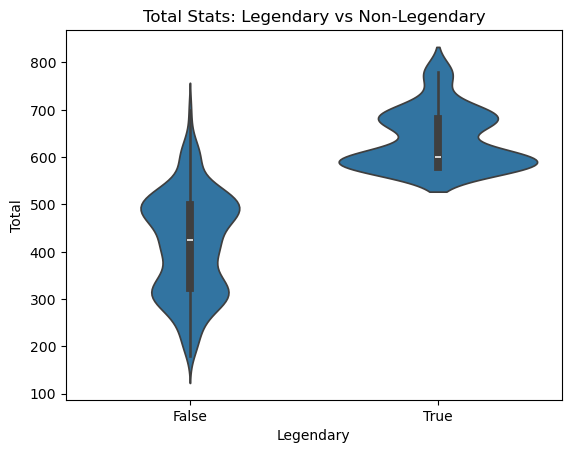

In [25]:
# Using a violin plot.

sns.violinplot(data=pokemon_df, x="Legendary", y="Total")
plt.title("Total Stats: Legendary vs Non-Legendary")
plt.show()

**Answer:** Yes. Legendary pokemon tend to have higher total stats compared to non-legendary pokemon. 

### Is there power creep in later generations (that is, do later generations of pokemon have higher total stats)?

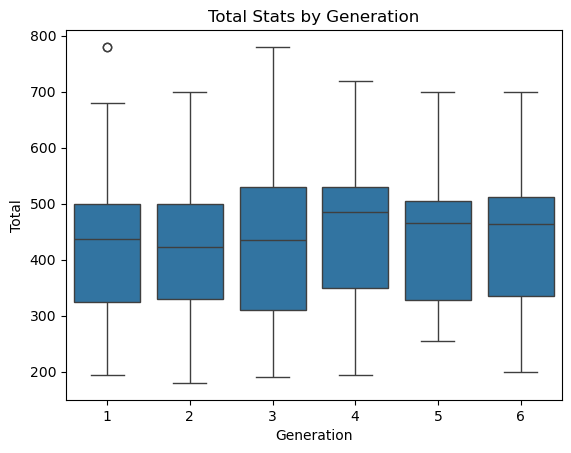

In [27]:
# Using a boxplot.

sns.boxplot(data=pokemon_df, x="Generation", y="Total")
plt.title("Total Stats by Generation")
plt.show()

**Answer:** Surprisingly, there's no noticeable power creep. The medians seem to stay between 400-500 and the distribution of total stats hasn't really changed.

### How is the speed stat distributed among pokemon's primary types?

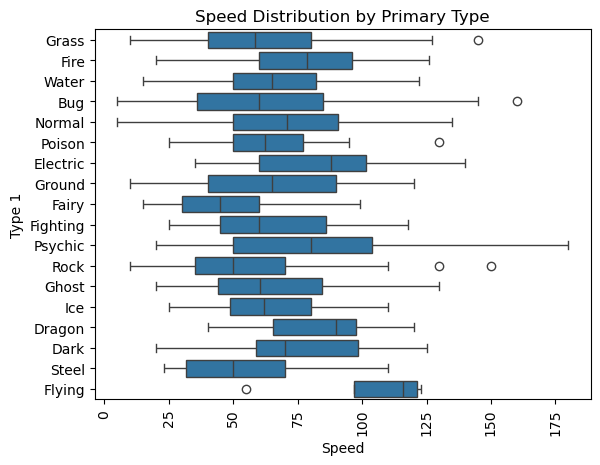

In [29]:
# Boxplot again.

sns.boxplot(data=pokemon_df, x="Speed", y="Type 1")
plt.xticks(rotation=90)
plt.title("Speed Distribution by Primary Type")
plt.show()

**Answer:** Psychic types have the highest maximum speed (wow!), but flying types (unsurprisingly?) have the highest overall speed across pokemon in that category, since you can see that their 25 - 75% quartiles are very far ahead of every other type's. The slowest minimum speed goes to either Bug or Normal types (the graph doesn't really display this well), and fairy types have the lowest speed as their 25 - 75% quartiles are the most concentrated at the lower end.